### Preprocessing Time-Series Data

With adaptation from  [Pact/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E )

Redo processing with Cudf.

Use Smart Meters Kaggle dataset from Kaggle for experiment setting to go over main activities(pre-processing, visualization, decomposition, forcasting, feature engineering, deep learning with time series).

Dataset is free - open data, available at Kaggle site. The dataset has energy consumption readings for a sample of close to 5.5k households that took part in the
UK power networks project between November 2011 and February 2014. Readings were taken at half hourly intervals. Some metadata about the
households are also available as part of the dataset.

The dataset has the time series data preprocessed on a daily level and combined in all the separate files, etc. We use raw files, block-0-111 in hhblock_dataset folder.

### Preprocessing Data

#### Accelerating Pandas with GPU using RAPIDS cuDF

Use the cudf.pandas extension to accelerate standard pandas code using the GPU.

In [ ]:
%load_ext cudf.pandas
import pandas as pd # Ensure pandas is imported before calling tqdm.pandas()
import tqdm as tqdm_module # Import the tqdm module under an alias to avoid name collision
import cudf
import numpy as np

# Standard pandas code now runs on GPU via the extension
# or use cudf directly for native GPU performance
import os, pathlib
from pathlib import Path

In [ ]:
np.random.seed()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.__version__, torchvision.__version__, torchaudio.__version__,

('2.11.0+cu128', '0.26.0+cu128', '2.11.0+cu128')

In [ ]:
src_data = Path('/content')
block_ds_path = src_data/"hhblock_dataset/hhblock_dataset"

In [ ]:
''' max date across all blocks '''
max_date = None
for file in tqdm(block_ds_path.glob('*.csv')):
  df = cudf.read_csv(file)
  df['day'] = cudf.to_datetime(df['day'])
  if max_date is None:
    max_date = df['day'].max() #df.groupby('LCLid')['day'].max()
  else:
    #max_data = pd.concat([max_data, df.groupby('LCLid')['day'].max()])
    if df['day'].max() > max_date:
      max_date = df['day'].max()
print(f'max date across all blocks: {max_date}')
del df

0it [00:00, ?it/s]

max date across all blocks: 2014-02-27 00:00:00


Reshape the data frame into the long form with hour block

Transform the Data in Compact Form (use cudf)

In [ ]:
''' Compact form '''
import gc # Ensure gc is imported for cuDF functions that might use it

def preprocess_compact(x_group_cudf, max_date_val):
  start_date = x_group_cudf['day'].min()
  name = x_group_cudf['LCLid'].iloc[0] # cuDF equivalent of .unique()[0]

  # Generate all days from start_date to max_date
  all_days = cudf.date_range(start=start_date, end=max_date_val, freq='1D')

  # Generate all hour blocks and offsets
  all_hour_blocks_list = [f'hh_{i}' for i in range(48)]
  all_offsets_list = list(range(48))

  # Create cuDF Series from lists for cartesian product
  full_day_df = cudf.DataFrame({'day': all_days, '_key': 1})
  full_hour_block_df = cudf.DataFrame({
      'hour_block': cudf.Series(all_hour_blocks_list),
      'offset': cudf.Series(all_offsets_list),
      '_key': 1
  })

  # Perform a Cartesian product using merge on a dummy key
  full_grid_cudf = full_day_df.merge(full_hour_block_df, on='_key').drop(columns=['_key'])

  # Add the LCLid to the full grid for the merge
  full_grid_cudf['LCLid'] = name

  # Merge the full grid with the actual consumption data (x_group_cudf)
  merged_df_cudf = full_grid_cudf.merge(
      x_group_cudf[['LCLid', 'day', 'hour_block', 'offset', 'energy_consumption']],
      on=['LCLid', 'day', 'hour_block', 'offset'],
      how='left'
  )

  # Sort values
  merged_df_cudf = merged_df_cudf.sort_values(['day', 'offset'])

  # Extract time series as a numpy array. Missing data will be NaN.
  # This will result in object dtype when put into a cuDF DataFrame later.
  ts = merged_df_cudf['energy_consumption'].to_numpy()
  len_ts = len(ts)
  gc.collect() # Clean up GPU memory

  return start_date, name, ts, len_ts

In [ ]:
def load_block_compact(block_df_cudf, freq='30min',
    ts_identifier='series_name', value_name='series_value'):
  groups_ = block_df_cudf.groupby('LCLid')
  all_ts_data = []
  all_start_dates, all_names, all_len = [], [], []

  # max_date is a global variable defined in a previous cell, it's a datetime object
  # which cudf.date_range can handle.
  global max_date

  # Iterate through groups. tqdm is for pandas, not directly for cudf groupby iterations.
  for name, group_cudf in groups_:
    start_date, name_val, ts, len_ts = preprocess_compact(group_cudf, max_date)
    all_start_dates.append(start_date)
    all_names.append(name_val)
    all_ts_data.append(ts)
    all_len.append(len_ts)

  all_data = {}
  all_data[ts_identifier] = cudf.Series(all_names)
  all_data['start_timestamp'] = cudf.Series(all_start_dates)
  all_data['frequency'] = cudf.Series([freq] * len(all_names))
  all_data[value_name] = cudf.Series(all_ts_data) # This column will be object dtype (numpy arrays)
  all_data['series_length'] = cudf.Series(all_len)
  gc.collect()

  return cudf.DataFrame(all_data)

Transform the Data in Expanded Form

In [ ]:
''' read and combine all the block data into single dataframe using cudf '''

# Ensure we are using the detected data path
blk_df_list = []
csv_files = sorted(list(block_ds_path.glob('*.csv')))

for file in tqdm(csv_files, desc='processing blocks ...'):
    # Use cudf to read the CSV on GPU
    # Note: cudf.read_csv handles parse_dates differently, we'll convert manually for clarity
    blk_df = cudf.read_csv(file, parse_dates=None)

    # GPU-accelerated datetime conversion
    blk_df['day'] = cudf.to_datetime(blk_df['day'])

    # Filtering on GPU
    blk_df = blk_df.loc[blk_df['day'] >= '2012-01-01']

    # Reshape (stack/unpivot) using cudf.melt for high performance
    id_vars = ['LCLid', 'day']
    value_vars = [col for col in blk_df.columns if col.startswith('hh_')]

    blk_df = blk_df.melt(id_vars=id_vars, value_vars=value_vars, var_name='hour_block', value_name='energy_consumption')

    # GPU string manipulation to extract offset
    blk_df['offset'] = blk_df['hour_block'].str.replace('hh_', '').astype(int)

    # Now load_block_compact accepts a cudf DataFrame directly
    blk_df_list.append(
        load_block_compact(blk_df, freq='30min', ts_identifier='LCLid', value_name='energy_consumption'))

    del blk_df, value_vars # Removed pdf from deletion as it's no longer created
    #gc.collect()

processing blocks ...:   0%|          | 0/112 [00:00<?, ?it/s]

In [ ]:
if 'blk_df_list' in locals() and len(blk_df_list) > 0:
    # blk_df_list already contains cudf DataFrames from the previous step
    hhblock_df = cudf.concat(blk_df_list)
    print(f"Successfully concatenated {len(blk_df_list)} blocks using cuDF.")
    display(hhblock_df.head(1))
else:
    print("Error: blk_df_list is empty. Please run the processing cell above first.")

Successfully concatenated 112 blocks using cuDF.


,LCLid,start_timestamp,frequency,energy_consumption,series_length
0,MAC000002,2012-10-13,30min,"[0.263, 0.269, 0.275, 0.256, 0.211000000000000...",24144


In [ ]:
print(hhblock_df.memory_usage(deep=True))
print(f' total {hhblock_df.memory_usage(deep=True).sum()/(1024**2)} MB')

Index                      44480
LCLid                      72284
start_timestamp            44480
frequency                  50044
energy_consumption    1408051748
series_length              44480
dtype: int64
 total 1343.066707611084 MB


#### Merge Additional Data

Read Household Data

In [ ]:
household_info = cudf.read_csv('informations_households.csv')
hhblock_df = hhblock_df.merge(household_info, on='LCLid', how='left')
hhblock_df.head()[:1]

,LCLid,start_timestamp,frequency,energy_consumption,series_length,stdorToU,Acorn,Acorn_grouped,file
0,MAC000002,2012-10-13,30min,"[0.263, 0.269, 0.275, 0.256, 0.211000000000000...",24144,Std,ACORN-A,Affluent,block_0


Read Bank Holiday Data

In [ ]:
# Load bank holidays using cuDF
bank_holidays_gpu = cudf.read_csv('uk_bank_holidays.csv')

# Convert to datetime on GPU
bank_holidays_gpu['Bank holidays'] = cudf.to_datetime(bank_holidays_gpu['Bank holidays'])

# Set index and display
bank_holidays_gpu = bank_holidays_gpu.set_index('Bank holidays')
print("Bank holidays processed with cuDF:")
display(bank_holidays_gpu.head())

Bank holidays processed with cuDF:


,Type
Bank holidays,
2012-12-26,Boxing Day
2012-12-25,Christmas Day
2012-08-27,Summer bank holiday
2012-05-06,Queen?s Diamond Jubilee (extra bank holiday)
2012-04-06,Spring bank holiday (substitute day)


Read Weather Data

In [ ]:
# Load weather data using cuDF
weather_hr_gpu = cudf.read_csv('weather_hourly_darksky.csv')

# Convert 'time' to datetime on GPU
weather_hr_gpu['time'] = cudf.to_datetime(weather_hr_gpu['time'])

# Set index and perform resampling on GPU
# cuDF resample requires the dataframe to be sorted by the index
weather_hr_gpu = weather_hr_gpu.set_index('time').sort_index()
weather_hr_gpu = weather_hr_gpu.resample('30min').ffill()

print("Weather data processed and resampled with cuDF:")
display(weather_hr_gpu.head())

Weather data processed and resampled with cuDF:


,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
time,,,,,,,,,,,
2011-11-01 00:00:00,13.63,160,13.49,11.48,1008.14,13.49,3.11,rain,clear-night,0.88,Clear
2011-11-01 00:30:00,13.63,160,13.49,11.48,1008.14,13.49,3.11,rain,clear-night,0.88,Clear
2011-11-01 01:00:00,13.26,154,12.73,11.58,1007.88,12.73,3.08,rain,partly-cloudy-night,0.93,Partly Cloudy
2011-11-01 01:30:00,13.26,154,12.73,11.58,1007.88,12.73,3.08,rain,partly-cloudy-night,0.93,Partly Cloudy
2011-11-01 02:00:00,12.94,161,13.65,12.14,1007.09,13.65,3.71,rain,clear-night,0.91,Clear


In [ ]:
''' resampling '''
weather_hr_gpu = weather_hr_gpu.resample('30min').ffill()
weather_hr_gpu.head()[:1]

,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
time,,,,,,,,,,,
2011-11-01,13.63,160,13.49,11.48,1008.14,13.49,3.11,rain,clear-night,0.88,Clear


Merge the block data with the additional information

In [ ]:
def map_weather_holidays_gpu(row, weather_gpu, holidays_gpu):
    """GPU-accelerated version of mapping weather and holidays."""
    # Create a range for the specific series length
    date_range = cudf.date_range(row['start_timestamp'], periods=row['series_length'], freq=row['frequency'])

    # Create a temporary cudf DataFrame to perform the join on GPU
    temp_df_gpu = cudf.DataFrame(index=cudf.to_datetime(date_range))

    # Join with holidays and weather datasets already on GPU
    # Using left join to maintain the time series length
    joined_gpu = temp_df_gpu.join(holidays_gpu, how='left').fillna('NO_HOLIDAY')
    joined_gpu = joined_gpu.join(weather_gpu, how='left')

    # Extract values back to the row
    row['holidays'] = joined_gpu['Type'].to_arrow().to_pylist()

    for col in weather_gpu.columns:
        row[col] = joined_gpu[col].to_arrow().to_pylist()
    del temp_df_gpu, joined_gpu
    # The original code incorrectly tried to delete `weather_gpu` which is a global variable.
    # gc.collect() # Clean up GPU memory for temporary objects
    return row

Process the Data in chunks  

In [ ]:
# Convert hhblock_df to a pandas DataFrame for applying the complex UDF.
# This bypasses the Numba compilation issues of cudf.apply(axis=1).

#processed_chunks = []
chunk_size = 10

for i in tqdm(range(0, len(hhblock_df), chunk_size), desc="Processing hhblock_df in chunks"):
    current_chunk = hhblock_df.iloc[i:i + chunk_size]
    current_chunk_pd = current_chunk.to_pandas()

    # Apply the GPU-accelerated mapping function using pandas.DataFrame.apply.
    # The map_weather_holidays_gpu function will still leverage cudf internally
    # for its operations (date_range, DataFrame creation, joins).
    # The .apply(pd.Series) is used to convert the Series of dicts/Series returned
    # by the first apply into a proper DataFrame.
    processed_chunk_pd = current_chunk_pd.apply(
        lambda r: map_weather_holidays_gpu(r, weather_hr_gpu, bank_holidays_gpu), axis=1
    ).apply(pd.Series)

    # Convert the processed pandas DataFrame back to cudf DataFrame.
    # Note: Columns containing Python lists will be stored as object dtype and
    # will be CPU-backed, as cudf does not natively support list columns on GPU.
    processed_chunk_cudf = cudf.DataFrame(processed_chunk_pd)
    processed_chunks.append(processed_chunk_cudf)
    del processed_chunk_pd, processed_chunk_cudf, current_chunk_pd, current_chunk

    gc.collect()

Processing hhblock_df in chunks:   0%|          | 0/556 [00:00<?, ?it/s]

In [ ]:
# Concatenate all processed chunks into the final DataFrame
#hhblock_df_with_features = cudf.concat(processed_chunks)
hhblock_df_with_features = cudf.concat(processed_chunks)
display(hhblock_df_with_features.head(1))
gc.collect()

,LCLid,start_timestamp,frequency,energy_consumption,series_length,stdorToU,Acorn,Acorn_grouped,file,holidays,...,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
5000,MAC003756,2012-10-20,30min,"[0.195, 0.17700000000000002, 0.231, 0.261, 0.1...",23808,Std,ACORN-O,Adversity,block_89,"[NO_HOLIDAY, NO_HOLIDAY, NO_HOLIDAY, NO_HOLIDA...",...,"[282, 282, 272, 272, 253, 253, 249, 249, 243, ...","[11.91, 11.91, 11.450000000000001, 11.45000000...","[11.0, 11.0, 10.88, 10.88, 10.38, 10.38, 10.17...","[1010.75, 1010.75, 1011.16, 1011.16, 1012.0, 1...","[11.91, 11.91, 11.450000000000001, 11.45000000...","[2.65, 2.65, 2.29, 2.29, 2.4699999999999998, 2...","[rain, rain, rain, rain, rain, rain, rain, rai...","[partly-cloudy-night, partly-cloudy-night, par...","[0.9400000000000001, 0.9400000000000001, 0.960...","[Mostly Cloudy, Mostly Cloudy, Mostly Cloudy, ..."


4155

In [ ]:
print(hhblock_df_with_features.memory_usage(deep=True),)
print(f'total: {hhblock_df_with_features.memory_usage(deep=True).sum()/1024**2 } MB')

Save the file to disk

In [ ]:
hhblock_df_with_features.to_parquet('all_hhblock_df_full.parquet')

Procedure to combine all all_hhblock_df_setX.parquet files

In [ ]:
# Get a list of all parquet files matching the pattern
parquet_files = sorted(glob.glob('/content/compact_hhblock_df_set*.parquet'))

# Initialize an empty list to store the DataFrames
all_hhblock_dfs = []

# Loop through each file, read it into a cuDF DataFrame, and append to the list
print(f"Found {len(parquet_files)} parquet files:")
for file in parquet_files:
    print(f"  - {file}")
    df = cudf.read_parquet(file)
    all_hhblock_dfs.append(df)
    gc.collect()

In [ ]:
# Concatenate all DataFrames into a single one
if all_hhblock_dfs:
    combined_hhblock_df = cudf.concat(all_hhblock_dfs)
    print(f"\nSuccessfully concatenated {len(all_hhblock_dfs)} files.")
    print(f"Combined DataFrame shape: {combined_hhblock_df.shape}")
else:
    print("No parquet files found to combine.")
    combined_hhblock_df = None

In [ ]:
if combined_hhblock_df is not None:
    print("Head of the combined DataFrame:")
    display(combined_hhblock_df.head())
    print("\nMemory usage of the combined DataFrame:")
    print(combined_hhblock_df.memory_usage(deep=True))
    print(f'total: {combined_hhblock_df.memory_usage(deep=True).sum()/1024**2 } MB')
else:
    print("Cannot display head or memory usage: no combined DataFrame was created.")


Head of the combined DataFrame:


,LCLid,file,Acorn_grouped,start_timestamp,frequency,energy_consumption,series_length
0,MAC000002,block_0,Affluent,2012-10-13,30min,"[0.263, 0.269, 0.275, 0.256, 0.211000000000000...",24144
1,MAC000246,block_0,Affluent,2012-01-01,30min,"[0.509, 0.31700000000000006, 0.253, 0.24900000...",37872
2,MAC000450,block_0,Affluent,2012-03-23,30min,"[1.337, 1.426, 0.996, 0.971, 0.994000000000000...",33936
3,MAC001074,block_0,ACORN-,2012-05-09,30min,"[0.18, 0.08600000000000001, 0.1060000000000000...",31680
4,MAC003223,block_0,Affluent,2012-09-18,30min,"[0.07600000000000001, 0.079, 0.123000000000000...",25344



Memory usage of the combined DataFrame:
Index                      44480
LCLid                      72284
file                       66789
Acorn_grouped              72999
start_timestamp            44480
frequency                  50044
energy_consumption    1408051748
series_length              44480
dtype: int64
total: 1343.2000198364258 MB


In [ ]:
combined_hhblock_df.to_parquet('all_hhblock_df_1-n.parquet')

### Handling Missing Data

In [ ]:
hhblock_df = pd.read_parquet('all_hhblock_df.parquet')

Take all the consumers blocks or a subset

In [ ]:
exp_block_df = compact_to_expanded(
    block_df, timeseries_col='energy_consumption',
    static_cols=['frequency', 'series_length', 'stdorToU', 'Acorn', 'Acorn_grouped'],
    time_varying_cols=['pressure', 'apparentTemperature', 'windSpeed', 'precipType', 'icon', 'humidity', 'summary'], ts_identifier='LCLid')

#### Baseline

Missing Data and Imputation Techniques

For the missing data instead of picking a window where data is missing instead where data is present, we either remove the missing data or fill them up.

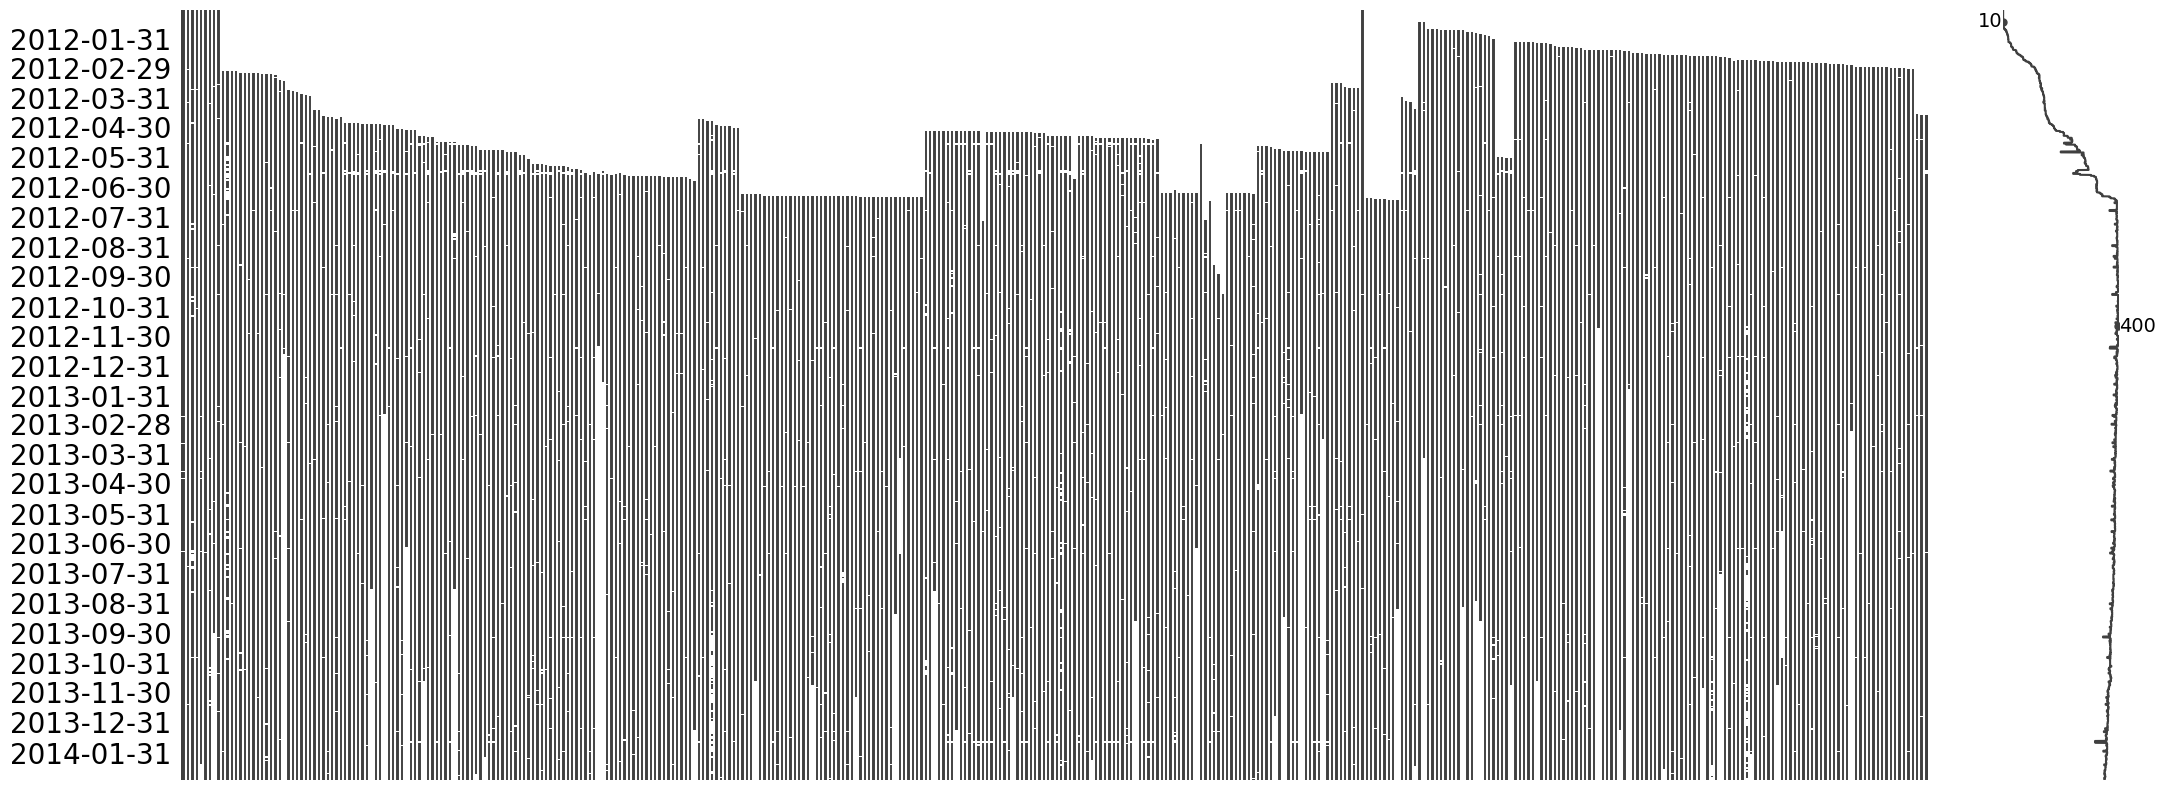

In [ ]:
#Pivot data to set index as datetime and different time series along columns
import missingno as msno
plot_df_ = pd.pivot_table(exp_block_df, index='timestamp', columns='LCLid', values='energy_consumption')
msno.matrix(plot_df_, freq='ME')
plt.show()

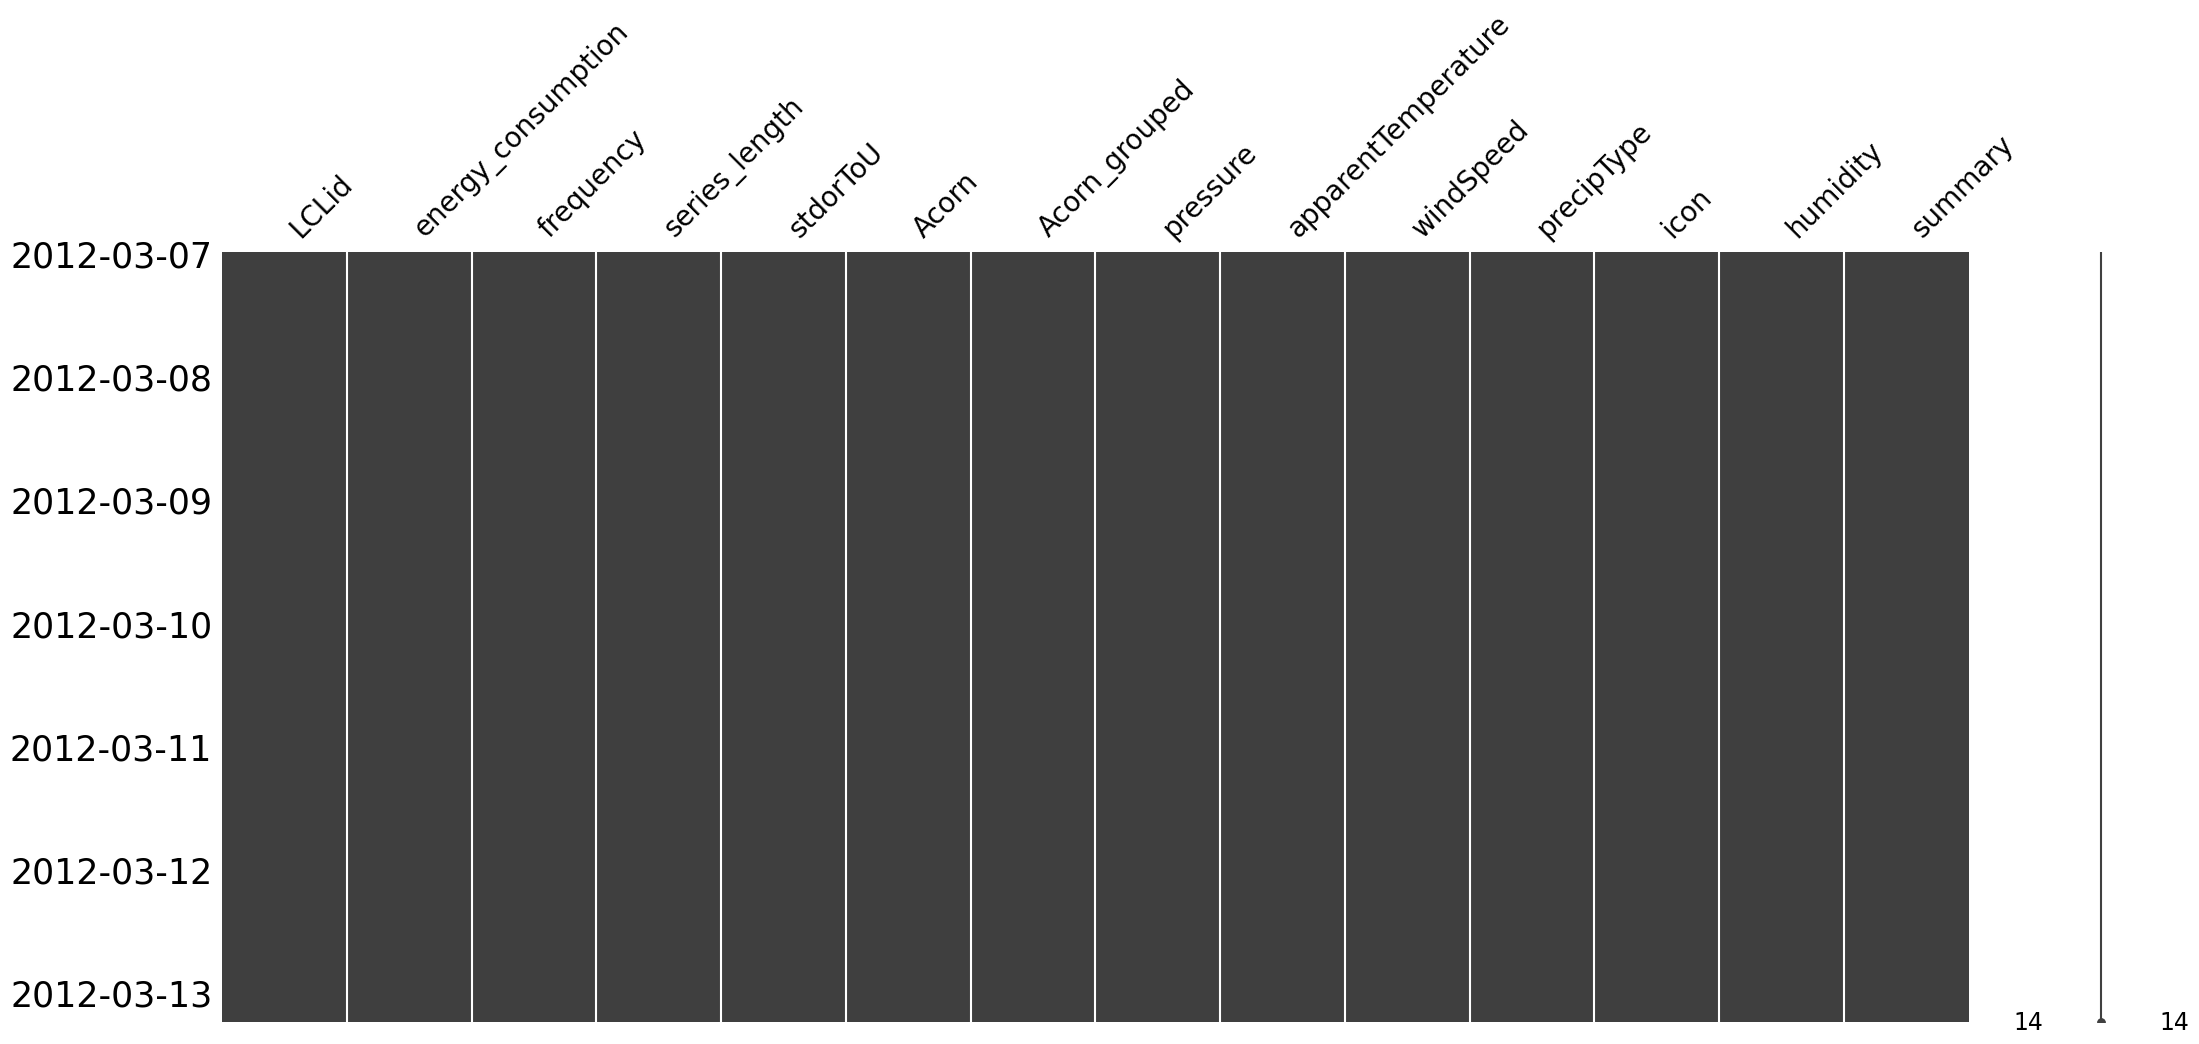

In [ ]:
# take a single timeseries block from the data
ts_df = exp_block_df[exp_block_df.LCLid=="MAC000322"].set_index("timestamp")
msno.matrix(ts_df[:300], freq="D", fontsize=20)
plt.show()

Create a missing data section to impoute the data and assess how the imputation technique works.

In [ ]:
# The dates between which we are nulling out the time series
window = slice("2012-10-07", "2012-10-08")
# Creating a new column and artificially creating missing values
ts_df['energy_consumption_missing'] = ts_df.energy_consumption
ts_df.loc[window, "energy_consumption_missing"] = np.nan
# Creating a new window with a few dats added on either side for visualization
vis_window =  slice(pd.to_datetime(window.start) - pd.Timedelta(days=2),
                    pd.to_datetime(window.stop) + pd.Timedelta(days=2))

In [ ]:
fig = px.line(ts_df[vis_window], y="energy_consumption_missing", title=f"MAC000322 Energy Consumption between {vis_window.start.strftime('%Y-%m-%d')} and {vis_window.stop.strftime('%Y-%m-%d')}")

fig.show()

In [ ]:
fig = px.line(ts_df[vis_window], y="energy_consumption_missing", title=f"MAC000322 Energy Consumption between {vis_window.start.strftime('%Y-%m-%d')} and {vis_window.stop.strftime('%Y-%m-%d')}")

fig.show()

Missing Data Imputation

In [ ]:
null_mask = ts_df.energy_consumption_missing.isnull()

Previous day

In [ ]:
from sklearn.metrics import mean_absolute_error

ts_df['prev_day'] = ts_df['energy_consumption'].shift(48)
ts_df['prev_day_imputed'] = ts_df['energy_consumption_missing']
ts_df.loc[null_mask, 'prev_day_imputed'] = ts_df.loc[null_mask,'prev_day']
mae = mean_absolute_error(ts_df.loc[ window, 'prev_day_imputed'], ts_df.loc[window, "energy_consumption"])

In [ ]:
plot_df = pd.melt(ts_df.loc[window,['energy_consumption','prev_day_imputed']].reset_index(), id_vars='timestamp', var_name='series')
fig = px.line(plot_df, x="timestamp", y=["value"], line_dash="series",         title=f"Imputing with Previous Day | MAE={mae:.3f}")
fig = format_plot(fig, ['Original', 'Previous Day Imputed'])
fig

Hourly profile

In [ ]:
ts_df["hour"] = ts_df.index.hour
hourly_profile = ts_df.groupby(['hour'])['energy_consumption'].mean().reset_index()
hourly_profile.rename(columns={'energy_consumption': 'hourly_profile'}, inplace=True)
idx = ts_df.index
ts_df = ts_df.merge(hourly_profile, on=['hour'], how='left', validate= 'many_to_one')
ts_df.index = idx

ts_df['hourly_profile_imputed'] = ts_df['energy_consumption_missing']
ts_df.loc[null_mask, 'hourly_profile_imputed'] = ts_df.loc[null_mask,'hourly_profile']
mae = mean_absolute_error(ts_df.loc[window, 'hourly_profile_imputed'], ts_df.loc[window, 'energy_consumption'])

In [ ]:
plot_df = pd.melt(ts_df.loc[window,['energy_consumption','hourly_profile_imputed']].reset_index(), id_vars='timestamp', var_name='series')

fig = px.line(plot_df, x="timestamp", y=["value"], line_dash="series", title=f'Imputing with Hourly Profile | MAE={mae:.3f}')
fig

Weekly hourly profile

In [ ]:
ts_df["weekday"] = ts_df.index.weekday
day_hourly_profile = ts_df.groupby(['weekday','hour'])['energy_consumption'].mean().reset_index()
day_hourly_profile.rename(columns={"energy_consumption": "day_hourly_profile"}, inplace=True)
idx = ts_df.index

ts_df = ts_df.merge(day_hourly_profile, on=['weekday', 'hour'], how='left', validate='many_to_one')
ts_df.index = idx

#Using the day-hourly profile to fill missing
ts_df['day_hourly_profile_imputed'] = ts_df['energy_consumption_missing']
ts_df.loc[null_mask,"day_hourly_profile_imputed"] = ts_df.loc[null_mask, 'day_hourly_profile']
mae = mean_absolute_error(ts_df.loc[window, 'day_hourly_profile_imputed'], ts_df.loc[window, 'energy_consumption'])

In [ ]:
plot_df = pd.melt(ts_df.loc[window,['energy_consumption', 'day_hourly_profile_imputed']].reset_index(), id_vars='timestamp', var_name='series')

fig = px.line(plot_df, x="timestamp", y=["value"], line_dash="series", title=f'Imputing with Week Day-Hourly Profile | MAE={mae:.3f}')
fig = format_plot(fig, ['Original', 'Week Day-Hourly Profile Imputed'])

fig

In [ ]:
px.line(ts_df.loc['2012-10-15': '2012-10-21',['day_hourly_profile','weekday']].reset_index(), x='timestamp', y='day_hourly_profile', color='weekday', title='Hourly Profiles by Weekday (Monday - Sunday)')

Seasonal Interpolation

In [ ]:
recovered_mx_iterp_weekday_half_hour = SeasonalInterpolation(
    seasonal_period=48*7,
    decomposition_strategy='additive',
    interpolation_strategy='spline',
    interpolation_args={'order':3},
    min_value=0).fit_transform(
        ts_df.energy_consumption_missing.values.reshape(-1,1))

ts_df['seas_interp_weekday_half_hour_imputed'] = recovered_mx_iterp_weekday_half_hour

mae_weekday_half_hour = mean_absolute_error(
    ts_df.loc[window, 'seas_interp_weekday_half_hour_imputed'],
    ts_df.loc[window, 'energy_consumption'])

In [ ]:
recovered_mx_interp_half_hour = SeasonalInterpolation(
    seasonal_period=48,
    decomposition_strategy='additive',
    interpolation_strategy='spline',
    interpolation_args={'order':3},
    min_value=0).fit_transform(
        ts_df.energy_consumption_missing.values.reshape(-1,1))

ts_df['seas_interp_half_hour_imputed'] = recovered_mx_interp_half_hour

mae_half_hour = mean_absolute_error(
    ts_df.loc[window, 'seas_interp_half_hour_imputed'],
    ts_df.loc[window, 'energy_consumption'])

In [ ]:
plot_df = pd.melt(ts_df.loc[window,['energy_consumption', 'seas_interp_half_hour_imputed', 'seas_interp_weekday_half_hour_imputed']].reset_index(), id_vars='timestamp', var_name='series')

fig = px.line(plot_df, x="timestamp", y=["value"], line_dash="series", title=f'Imputing with Seasonal Interpolation <br> MAE Half Hourly={mae_half_hour:.3f} | MAE Weekday-Half Hourly={mae_weekday_half_hour:.3f}')

fig = format_plot(fig, ['Original', 'Half Hourly Profile Imputed', 'Week Day-Half Hourly Profile Imputed'], title_font_size=16)

fig

Summary of Seasonal Interpolation

In [ ]:
imputed_columns = [col for col in ts_df.columns if "imputed" in col]
original_col = "energy_consumption"

In [ ]:
act = ts_df.loc[window, original_col].values
mae_d = {}
for col in imputed_columns:
	mae_d[col] = mean_absolute_error(act, ts_df.loc[window, col].values)

In [ ]:
mae_d.keys()

dict_keys(['prev_day_imputed', 'hourly_profile_imputed', 'day_hourly_profile_imputed', 'seas_interp_weekday_half_hour_imputed', 'seas_interp_half_hour_imputed'])

In [ ]:
res_df = pd.DataFrame.from_dict(mae_d, orient="index").reset_index()
res_df.columns=["Imputation", "MAE"]
res_df.Imputation = res_df.Imputation.map({
 'prev_day_imputed': "Previous Day",
 'hourly_profile_imputed': "Hourly Profile",
 'day_hourly_profile_imputed': "Day-Hourly Profile",
 'seas_interp_weekday_half_hour_imputed': "Seasonal Interpolation Weekday-Half Hourly",
 'seas_interp_half_hour_imputed': "Seasonal Interpolation Half Hourly"
})

In [ ]:
res_df

,Imputation,MAE
0,Previous Day,0.075927
1,Hourly Profile,0.052225
2,Day-Hourly Profile,0.052853
3,Seasonal Interpolation Weekday-Half Hourly,0.054936
4,Seasonal Interpolation Half Hourly,0.053962


### Seasonal Decomposition

In [ ]:
# Taking a single time series from the block
ts_df = exp_block_df[exp_block_df.LCLid=="MAC000322"].set_index("timestamp")

''' Handling Missing Data '''
ts = SeasonalInterpolation(seasonal_period=48*7).fit_transform(ts_df.energy_consumption.values.reshape(-1,1)).squeeze()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
#Does not support misssing values, so using imputed ts instead
res = seasonal_decompose(ts, period=7*48, model="additive", extrapolate_trend="freq", filt=np.repeat(1/(30*48), 30*48))

fig = decomposition_plot(ts_df.index, res.observed, res.seasonal, res.trend, res.resid)
fig

In [ ]:
#Let's zoom in on a few days to better see the seasonality extracted
fig.update_xaxes(type="date", range=["2012-11-4", "2012-12-4"])
fig

Seasonality and Trend Decomposition using Loess (STL)

In [ ]:
#Supports missing values and expects a series or dataframe with datetime index
stl = STL(seasonality_period=7*48, model = "additive")
res_new = stl.fit(ts_df.energy_consumption)

fig = res_new.plot(interactive=True, )
fig

In [ ]:
#Let's zoom in on a few days to better see the seasonality extracted
fig.update_xaxes(type="date", range=["2012-11-4", "2012-12-4"])
fig

Seasonality and Trend Decomposition using Loess and Fourier Terms (Fourier Decomposition)

In [ ]:
#Doesn't support missing values, and expects a series or datafeame with datetime index
stl = FourierDecomposition(seasonality_period="hour", model = "additive", n_fourier_terms=5)
res_new = stl.fit(pd.Series(ts.squeeze(), index=ts_df.index))

fig = res_new.plot(interactive=True)
fig

In [ ]:
fig.update_xaxes(type="date", range=["2012-11-4", "2012-12-4"])
fig

Custom Seasonality

In [ ]:
#Making a custom seasonality term
ts_df["dayofweek"] = ts_df.index.dayofweek
ts_df["hour"] = ts_df.index.hour
#Creating a sorted unique combination df
map_df = ts_df[["dayofweek","hour"]].drop_duplicates().sort_values(["dayofweek", "hour"])
# Assigning an ordinal variable to capture the order
map_df["map"] = np.arange(1, len(map_df)+1)
# mapping the oprdinal mapping back to the original df and getting the seasonality array
seasonality = ts_df.merge(map_df, on=["dayofweek","hour"], how='left', validate="many_to_one")['map']

In [ ]:
stl = FourierDecomposition(model = "additive", n_fourier_terms=50)
res_new = stl.fit(pd.Series(ts, index=ts_df.index), seasonality=seasonality)

fig = res_new.plot(interactive=True)
fig

In [ ]:
fig.update_xaxes(type="date", range=["2012-11-4", "2012-12-4"])
fig

Multiple Seasonality Decomposition using Loess (MSTL)

Using Averages as the seasonal model

In [ ]:
stl = MultiSeasonalDecomposition(seasonal_model="averages",seasonality_periods=[48*7, 48], model = "additive")
res_new = stl.fit(pd.Series(ts, index=ts_df.index))

fig = res_new.plot(interactive=True)
fig

In [ ]:
fig.update_xaxes(type="date", range=["2012-11-4", "2012-12-4"])
fig

Using Fourier Decomposition as seasonal model

In [ ]:
stl = MultiSeasonalDecomposition(seasonal_model="fourier",seasonality_periods=["day_of_year", "day_of_week", "hour"], model = "additive", n_fourier_terms=10)
res_new = stl.fit(pd.Series(ts, index=ts_df.index))

fig = res_new.plot(interactive=True)
fig

In [ ]:
fig.update_xaxes(type="date", range=["2012-11-4", "2012-12-4"])
fig

MSTL decomposition in STATSMODELS


break out time series up in to daily and weekly seasonal components.

In [ ]:
exp_block_df.head()

,timestamp,LCLid,energy_consumption,frequency,series_length,stdorToU,Acorn,Acorn_grouped,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,2012-03-07 00:00:00,MAC000322,0.125,30min,34704,Std,ACORN-D,Affluent,1024.14,2.65,3.76,rain,partly-cloudy-night,0.8,Partly Cloudy
1,2012-03-07 00:30:00,MAC000322,0.104,30min,34704,Std,ACORN-D,Affluent,1024.14,2.65,3.76,rain,partly-cloudy-night,0.8,Partly Cloudy
2,2012-03-07 01:00:00,MAC000322,0.133,30min,34704,Std,ACORN-D,Affluent,1023.40,2.53,4.39,rain,partly-cloudy-night,0.8,Partly Cloudy
3,2012-03-07 01:30:00,MAC000322,0.145,30min,34704,Std,ACORN-D,Affluent,1023.40,2.53,4.39,rain,partly-cloudy-night,0.8,Partly Cloudy
4,2012-03-07 02:00:00,MAC000322,0.109,30min,34704,Std,ACORN-D,Affluent,1022.34,2.47,4.83,rain,clear-night,0.8,Clear


In [ ]:
ts_df_mstl = exp_block_df[exp_block_df.LCLid=="MAC000322"][['timestamp','energy_consumption']].set_index('timestamp')
ts_df_mstl.head()

,energy_consumption
timestamp,
2012-03-07 00:00:00,0.125
2012-03-07 00:30:00,0.104
2012-03-07 01:00:00,0.133
2012-03-07 01:30:00,0.145
2012-03-07 02:00:00,0.109


In [ ]:
from statsmodels.tsa.seasonal import MSTL

stl_kwargs = {"seasonal_deg": 0, }
mstl = MSTL(pd.Series(ts, index=ts_df_mstl.index),
            periods=[48, 48*7],
            #windows=[101, 101],  # Setting this large along with `seasonal_deg=0` will force the seasonality to be periodic.
            stl_kwargs = stl_kwargs,
            )
mstl_result = mstl.fit()

In [ ]:
mstl_result.trend.head()

,trend
timestamp,
2012-03-07 00:00:00,0.118023
2012-03-07 00:30:00,0.117975
2012-03-07 01:00:00,0.117928
2012-03-07 01:30:00,0.117880
2012-03-07 02:00:00,0.117833


In [ ]:
print('Available attributes:', mstl_result.__dir__())
mstl_result.seasonal.head()
mstl_result.resid.head()

Available attributes: ['_seasonal', '_trend', '_weights', '_resid', '_observed', '__module__', '__firstlineno__', '__doc__', '__init__', 'observed', 'seasonal', 'trend', 'resid', 'weights', 'nobs', 'plot', '__static_attributes__', '__dict__', '__weakref__', '__annotations__', '__new__', '__repr__', '__hash__', '__str__', '__getattribute__', '__setattr__', '__delattr__', '__lt__', '__le__', '__eq__', '__ne__', '__gt__', '__ge__', '__reduce_ex__', '__reduce__', '__getstate__', '__subclasshook__', '__init_subclass__', '__format__', '__sizeof__', '__dir__', '__class__']


,resid
timestamp,
2012-03-07 00:00:00,-0.055863
2012-03-07 00:30:00,-0.044778
2012-03-07 01:00:00,-0.060302
2012-03-07 01:30:00,-0.068700
2012-03-07 02:00:00,-0.012164


In [ ]:
pd.Series(res.resid).head()

,0
0,-0.020022
1,-0.050802
2,-0.007052
3,-0.018353
4,-0.043556


In [ ]:
#sns.set_style("darkgrid")
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=13)

# Extracting components from MSTL result
observed_mstl = mstl_result.observed
trend_mstl = mstl_result.trend
# Summing the two seasonal components
seasonal_mstl = mstl_result.seasonal['seasonal_48'] + mstl_result.seasonal['seasonal_336']
remainder_mstl = mstl_result.resid

# Creating a plot using the decomposition_plot function
fig = decomposition_plot(ts_df_mstl.index, observed_mstl, seasonal_mstl, trend_mstl, remainder_mstl)

# Correctly setting the x-axis range for a Plotly figure
fig.update_xaxes(range=["2012-01-01", "2012-02-01"])

fig.show()

### Visualizations

In [ ]:
ts = SeasonalInterpolation(seasonal_period=48*7).fit_transform(ts_df.energy_consumption.values.reshape(-1,1)).squeeze()

In [ ]:
ts_df = exp_block_df[exp_block_df['LCLid'] == 'MAC000322'].set_index('timestamp')

ts_df['weekday_name'] = ts_df.index.day_name()
ts_df['weekday'] = ts_df.index.weekday
ts_df['week'] = ts_df.index.isocalendar().week
ts_df['hour'] = ts_df.index.hour
ts_df['month'] = ts_df.index.month
ts_df['day'] = ts_df.index.day
ts_df['month_name'] = ts_df.index.month_name()
ts_df['year'] = ts_df.index.year

ts_df['month_name'] = pd.Categorical(ts_df['month_name'],
  categories=['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October','November', 'December'])
ts_df['weekday_name'] = pd.Categorical(ts_df['weekday_name'],
  categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday',
              'Friday', 'Saturday', 'Sunday'])

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
ts_df['energy_consumption'] = SeasonalInterpolation(
    seasonal_period=48*7).fit_transform(ts_df['energy_consumption'].values.reshape(-1, 1))

figure = px.line(ts_df, y='energy_consumption', title='Energy consumption for MAC005492')
figure

In [ ]:
''' multi-variate line chart '''
figure__= two_line_plot_secondary_axis(x=ts_df.index,
    y1 = ts_df.energy_consumption, y2 = ts_df.LCLid,
    y1_name ='energy consumption', y2_name = 'Temperature',
    title = 'Temperature and energy consumption'
)
figure__.update_layout(
    legend=dict(orientation = 'h', yanchor = 'bottom', y = .98, xanchor = 'right',x = 1,),
    yaxis = dict( #title_text = ylabel,
        titlefont = dict(size = 10), tickfont = dict(size = 10),),
    xaxis = dict( #title_text = xlabel,
        titlefont = dict(size = 10), tickfont = dict(size = 10),)
)
figure__.show()

In [ ]:
''' calendar heatmap '''
plot_df = pd.pivot_table(ts_df, index='weekday_name', values='energy_consumption',
                         columns='hour', aggfunc='mean')
figure_ = px.imshow(plot_df, height=600, title='hours vs week-day energy consumption')
figure_ = format_plot(figure_, ylabel='Week Day', xlabel='Hours')
figure_.show()

In [ ]:
''' auto-correlation plots '''
stl = MultiSeasonalDecomposition(seasonal_model='fourier',
  seasonality_periods=['day_of_year', 'day_of_week', 'hour'], model = 'additive',
  n_fourier_terms =10)
res = stl.fit(ts_df['energy_consumption'])

figure_ = plot_autocorrelation(res.resid, vertical=True)
figure_.show()

#### Outlier Detection and Treatment

In [ ]:
res_df = pd.DataFrame(columns=['# of Outliers', '% of Outliers'])

In [ ]:
def detect_outlier_sd(ts, sd_multiple=2):
  mean = ts.mean()
  std = ts.std()
  higher_nound = mean + sd_multiple*std
  lower_nound = mean - sd_multiple*std
  outlier_mask = (ts > higher_nound) | (ts < lower_nound)
  return outlier_mask

def detect_outlier_iqr(ts, iqr_multiple=2):
  q1, q2, q3 = np.quantile(
      ts, 0.25), np.quantile(ts, 0.5), np.quantile(ts, 0.75)
  iqr = q3 - q1
  higher_nound = q3 + iqr_multiple*iqr
  lower_nound = q1 + iqr_multiple*iqr
  outlier_mask = (ts > higher_nound) | (ts < lower_nound)
  return outlier_mask

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
''' Fill in missing values '''
ts = SeasonalInterpolation(
    seasonal_period=48*7).fit_transform(ts_df['energy_consumption'].values.reshape(-1, 1))

outlier_mask = detect_outlier_sd(ts, sd_multiple=3)
res_df.loc['3SD', '# of Outliers'] = outlier_mask.sum()
res_df.loc['3SD', '% of Outliers'] = outlier_mask.sum()/len(ts)*100
res_df

In [ ]:
fig_ = plot_outliers(ts_df, ts, outlier_mask, method='Standard Deviation')
fig_.show()

In [ ]:
outlier_mask = detect_outlier_isolation_forest(ts, outlier_fraction=0.01)
res_df.loc["Isolation Forest", "# of Outliers"] = outlier_mask.sum()
res_df.loc["Isolation Forest", "% of Outliers"] = outlier_mask.sum()/len(ts)
fig = plot_outliers(ts_df.index, ts, outlier_mask, method="Isolation Forest")
format_plot(fig, xlabel="Time", ylabel="Energy Consumption")
fig.show()

In [ ]:
outlier_mask = detect_outlier_iqr(ts,4)
res_df.loc['4IQR', '# of Outliers'] = outlier_mask.sum()
res_df.loc['4IQR', '% of Outliers'] = outlier_mask.sum()/len(ts)*100
res_df

,# of Outliers,% of Outliers
3SD,805,2.319617
Isolation Forest,346,0.00997
4IQR,34333,98.930959


In [ ]:
fid = plot_outliers(ts_df, ts, outlier_mask, method='IQR')
format_plot(fid, xlabel="Time", ylabel="Energy Consumption")
fid.show()